# Where a ground state starts: every Potts solver at ten states, polished by ICM

Every ground-state solver of `search.ground_state` (issue #906), each run as a
start of the one seam `opt.starts.StartsBenchmark` (#894), each polished by the
same descent, iterated conditional modes to a local minimum, and each read
against what can referee an energy at this size (issue #927). The counterpart
of `emission_mixture_starts.ipynb` on a lattice: there a start seeds EM, here a
solver's labelling seeds ICM, and both are drawn by one figure.

Four terms the rest uses:

- The **energy** is `sim.potts.energy`, `-sum_n h[n, x_n] - J sum_(n,m) [x_n = x_m]`,
  lower being better; a **gap** is an energy less the reference. At `beta = 1`
  the energy is a labelling's negative log-weight, so a gap is in nats.
- A **`Budget`** (`opt.budget.Budget`) is a ceiling in a stated unit. Each
  solver spends `SWEEPS` heat-bath sweeps' worth of **site visits**, the unit
  `search.ground_state` bills every solver in, so a cluster move pays for the
  sites it touches; the polish spends **sweeps** of ICM until one changes
  nothing; and every (solver, seed) cell is held to `Budget(Cost.SECONDS, 120)`
  of wall clock, checked on the cells' own clocks.
- The **polish** is `search.potts_starts.polish_by_icm`: one index-order ICM
  sweep at a time from the solver's labelling, stopping at the first sweep that
  changes nothing. What separates two solvers is where they leave the labelling.
- The **seam** is `opt.starts.StartsBenchmark`, entered through
  `search.potts_starts`: the energy as an `Objective` whose `theta` is the
  labelling, a solver as an `Initializer`, ICM as a `Polisher`.

The instance is `spatio_only/release`, the size the coupled application runs
at: an open triangular 71x71 lattice, 5,041 sites, `q = 10` classes at
coupling 0.7, in a field tilted by each site's lognormal size over the class
ladder -0.9 to 0.9. No exact optimum is known at ten states and 5,041 sites, so
the energy is read against the **alpha-expansion bracket**: the expansion's own
energy, which the optimum is at most, and the lower end its factor-2 bound
gives. The second referee is the **structure** of the parameters that built the
field: the size tilt, the null class and the occupancy.

In [1]:
import functools
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Math, display
from snakes_and_ladders.cost import Cost
from snakes_and_ladders.opt.budget import Budget
from snakes_and_ladders.opt.starts import StartsBenchmark
from snakes_and_ladders.qa.starts import (
    gap_panels,
    gap_table,
    start_styles,
)
from snakes_and_ladders.qa.style import notebook_style
from snakes_and_ladders.search.mixture_starts import curve_band
from snakes_and_ladders.search.ground_state import (
    ANNEAL_END,
    ANNEAL_START,
    METHODS,
    N_REPLICAS,
    expansion_bracket,
    run_alpha_expansion,
    structure,
)
from snakes_and_ladders.search.potts_starts import (
    PottsObjective,
    SolverStart,
    describe,
    polish_by_icm,
    spatio_rung,
)
from snakes_and_ladders.sim.fixtures import fixture

np.set_printoptions(precision=3, suppress=True)

## The instance, and the reference its energies are read against

`fixture` reads the declared file, and `search.potts_starts.spatio_rung` builds
the rung from it at the fixture's own ten classes. Alpha-expansion is run once
at the solvers' budget for the bracket.

In [2]:
#: Heat-bath sweeps' worth of site visits each solver may spend: 1,000, the
#: #906 budget; 300 from #927 until #923 moved Swendsen-Wang and ICM in a
#: random order onto their compiled passes.
SWEEPS = 1000

# The declared instance: tests/regression/fixtures/spatio_only/release.yaml.
declared = fixture("spatio_only", "release").params
# The ten-state rung, with its ladder and sizes for the structural referee.
rung = spatio_rung(declared, "release-q10")
# The solvers' budget, in the site visits the rung's own sweeps cost.
SOLVER_BUDGET = Budget(Cost.SITE_VISITS, SWEEPS * rung.visits_per_sweep)
# The expansion's energy and the bracket its factor-2 bound gives: the
# reference every gap is read against.
REFERENCE = run_alpha_expansion(rung, SOLVER_BUDGET, np.random.default_rng(0)).energy
bracket = expansion_bracket(rung, REFERENCE)
print(
    f"{rung.n_nodes} sites, {len(rung.graph.edges)} edges, q = {rung.n_states}, "
    f"J = {float(np.asarray(rung.graph.edge_coupling)[0]):.4f}"
)
print(f"expansion {REFERENCE:.2f}, bracket [{bracket.lower:.2f}, {bracket.upper:.2f}]")

5041 sites, 14840 edges, q = 10, J = 0.7000
expansion -10454.16, bracket [-11521.58, -10454.16]


## The solvers

Each solver's description is the first paragraph of its own docstring in
`search.ground_state`, so the text cannot drift from the code. Every solver
spends `SWEEPS` sweeps' worth of site visits: the annealed ones from
`ANNEAL_START` to `ANNEAL_END`, tempering over `N_REPLICAS` rungs of the same
range, the graph-cut moves and belief propagation until they settle or the
visits run out.

In [3]:
ORDER = list(METHODS)
print(
    f"anneal from {ANNEAL_START} to {ANNEAL_END}; tempering over {N_REPLICAS} "
    f"replicas; {SWEEPS} sweeps = {SOLVER_BUDGET.size:,} site visits at q = {rung.n_states}"
)
for name in ORDER:
    # Each solver's own docstring, its first paragraph, and the move it fixes.
    print(f"{name:16s} {describe(name)}")

anneal from 2.0 to 0.05; tempering over 6 replicas; 1000 sweeps = 34,721,000 site visits at q = 10
greedy           The field-only labelling: every site takes its own best class, coupling ignored.
icm              Iterated conditional modes: single-site descent in index order.
icm-random       ICM in a random sweep order: the heat bath at T = 0, every sweep of the budget run.
anneal           One annealed run, its step count fixed before the run starts. Move set: single-site.
swendsen-wang    One annealed run, its step count fixed before the run starts. Move set: swendsen-wang.
wolff            One annealed run, its step count fixed before the run starts. Move set: wolff.
tempering        Parallel tempering over a geometric ladder, charged for every replica.
alpha-expansion  Alpha expansion: the only entry carrying a bound, and the bracket's lower end.
alpha-beta-swap  Alpha-beta swap: the cheaper move, and the one with no bound.
max-product      Max-product on the factor graph: MAP-ex

## Every solver, five seeds

`StartsBenchmark` runs each (solver, seed) cell on a pool of four worker
processes, each cell drawing from `default_rng([seed, instance])`; every
solver reads its generator, and the deterministic ones (greedy, the graph-cut
moves, belief propagation) return the same labelling at every seed. The
seeding budget is one evaluation, the solver's one labelling; the polish's is
a cap of `POLISH` sweeps it does not reach.

In [4]:
#: Seeds of every cell.
SEEDS = [0, 1, 2, 3, 4]
#: Cells run at once, one worker process per core of the 4-core host.
WORKERS = 4
#: ICM's cap, in sweeps; every polish here stops on a clean sweep first.
POLISH = Budget(Cost.SWEEPS, 200)
#: The wall clock any one cell may take.
CEILING = Budget(Cost.SECONDS, 120)

load_before = os.getloadavg()
opened = time.perf_counter()
# Every solver as a start on the rung, built per cell from its generator.
starts = {name: functools.partial(SolverStart, name, SOLVER_BUDGET) for name in ORDER}
result = StartsBenchmark(
    PottsObjective(rung),
    starts,
    polish_by_icm,
    seeding_budget=Budget(Cost.EVALUATIONS, 1),
    polish_budget=POLISH,
    seeds=SEEDS,
    workers=WORKERS,
    reference=[REFERENCE],
).run()
elapsed = time.perf_counter() - opened
load_after = os.getloadavg()

# Every cell's whole seconds, held to the ceiling.
longest = max(trial.seconds[-1] for name in ORDER for trial in result.trials(name))
cells = sum(len(result.trials(name)) for name in ORDER)
print(f"{cells} cells of {len(ORDER)} solvers at {len(SEEDS)} seeds")

55 cells of 11 solvers at 5 seeds


## What each solver handed over, and where ICM left it

Per solver, over the five seeds: the energy the solver handed over and its gap,
the gap where ICM stopped, the ICM sweeps, and how many seeds ended on the
reference exactly. The gap is above the expansion's energy, which is not the
optimum, so a negative gap is a labelling below the expansion and inside the
bracket. Energies and gaps are continuous in the seeds, and this cell is
compared.

In [5]:
def spread(values: list[float], digits: int = 2) -> str:
    # The mean, and the sample standard deviation beside it over the seeds.
    return f"{np.mean(values):.{digits}f} ± {np.std(values, ddof=1):.{digits}f}"


print(f"{rung.name}: reference {REFERENCE:.2f}")
print("| solver | handed over | init. gap | final gap | ICM sweeps | at reference |")
print("|---|---|---|---|---|---|")
for name in ORDER:
    trials = result.trials(name)
    print(
        f"| {name} | {spread([t.seeded_value for t in trials])} "
        f"| {spread([t.seeded_value - REFERENCE for t in trials])} "
        f"| {spread([t.value - REFERENCE for t in trials])} "
        f"| {spread([float(t.termination.iterations) for t in trials], 1)} "
        f"| {sum(abs(t.value - REFERENCE) < 1e-9 for t in trials)}/{len(trials)} |"
    )

release-q10: reference -10454.16
| solver | handed over | init. gap | final gap | ICM sweeps | at reference |
|---|---|---|---|---|---|
| greedy | -7418.10 ± 0.00 | 3036.06 ± 0.00 | 666.07 ± 0.00 | 9.0 ± 0.0 | 0/5 |
| icm | -8944.33 ± 72.54 | 1509.82 ± 72.54 | 1509.82 ± 72.54 | 1.0 ± 0.0 | 0/5 |
| icm-random | -8454.27 ± 75.15 | 1999.89 ± 75.15 | 1999.89 ± 75.15 | 1.0 ± 0.0 | 0/5 |
| anneal | -10316.14 ± 32.75 | 138.02 ± 32.75 | 137.99 ± 32.75 | 1.8 ± 0.4 | 0/5 |
| swendsen-wang | -9765.93 ± 40.76 | 688.23 ± 40.76 | 430.07 ± 16.45 | 6.2 ± 1.3 | 0/5 |
| wolff | -1476.93 ± 45.13 | 8977.23 ± 45.13 | 1532.63 ± 59.33 | 13.4 ± 1.1 | 0/5 |
| tempering | -9900.08 ± 24.45 | 554.07 ± 24.45 | 553.58 ± 24.38 | 2.6 ± 0.5 | 0/5 |
| alpha-expansion | -10454.16 ± 0.00 | 0.00 ± 0.00 | 0.00 ± 0.00 | 1.0 ± 0.0 | 5/5 |
| alpha-beta-swap | -10454.16 ± 0.00 | 0.00 ± 0.00 | 0.00 ± 0.00 | 1.0 ± 0.0 | 5/5 |
| max-product | -10160.50 ± 0.00 | 293.66 ± 0.00 | 293.66 ± 0.00 | 1.0 ± 0.0 | 0/5 |
| bifurcation | -98

## The structure the parameters say a ground state has

`search.ground_state.structure` reads a labelling against the ladder and the
sizes that built the field: the **tilt**, the mean class value of the largest
size quartile less the smallest's; the **null tilt**, the same for the class
whose value is zero, which carries no field anywhere; whether the mean rises
across all four quartiles; and the sites per class. Read at each solver's
polished labelling, seed 0.

In [6]:
print("| solver | tilt | null tilt | monotone | occupancy |")
print("|---|---|---|---|---|")
for name in ORDER:
    labelling = result.trials(name)[0].theta.numpy()
    shape = structure(rung.alpha, rung.sizes, labelling)
    print(
        f"| {name} | {shape.tilt:.3f} | {shape.null_tilt:.3f} "
        f"| {shape.monotone} | {shape.occupancy} |"
    )

| solver | tilt | null tilt | monotone | occupancy |
|---|---|---|---|---|
| greedy | 0.856 | 0.000 | True | (2464, 0, 0, 0, 0, 0, 0, 0, 0, 2577) |
| icm | 0.516 | -0.005 | True | (1084, 614, 485, 123, 187, 460, 93, 290, 497, 1208) |
| icm-random | 0.689 | 0.003 | True | (1277, 335, 290, 298, 237, 256, 211, 241, 588, 1308) |
| anneal | 0.382 | 0.000 | True | (2828, 88, 0, 0, 0, 0, 0, 0, 35, 2090) |
| swendsen-wang | 0.708 | 0.000 | True | (2603, 0, 0, 0, 0, 0, 0, 0, 0, 2438) |
| wolff | 0.522 | -0.007 | True | (893, 835, 262, 356, 435, 324, 277, 76, 503, 1080) |
| tempering | 0.420 | 0.006 | True | (1128, 742, 723, 0, 59, 160, 153, 179, 303, 1594) |
| alpha-expansion | 0.215 | 0.000 | True | (3286, 0, 0, 0, 0, 0, 0, 0, 0, 1755) |
| alpha-beta-swap | 0.215 | 0.000 | True | (3286, 0, 0, 0, 0, 0, 0, 0, 0, 1755) |
| max-product | 0.700 | 0.000 | True | (2423, 0, 0, 0, 0, 0, 0, 0, 0, 2618) |
| bifurcation | 0.126 | 0.017 | True | (2973, 113, 146, 62, 356, 1302, 75, 4, 0, 10) |


## What it cost in seconds

The seconds are the host's, so this cell is tagged `host-dependent` and its
text is not compared (`docs/nb/README.md`). The table is
`qa.starts.gap_table`'s five columns per solver: the seconds and the gap
in nats at the handover and where ICM ended, mean ± std over the seeds, the
rows from the lowest mean final gap, as
the LaTeX `tabular`, its caption and the `array` the notebook renders.

In [7]:
print(
    f"host: {os.cpu_count()} cores, {WORKERS} workers; 1-minute load "
    f"{load_before[0]:.2f} before and {load_after[0]:.2f} after; {cells} cells "
    f"took {elapsed:.0f} s, the longest cell {longest:.2f} s against the "
    f"{CEILING.size} s ceiling"
)
assert longest <= CEILING.size
tabular, caption, array = gap_table(result, unit="nats")
print(tabular)
print()
print(caption)
display(Math(array))

host: 4 cores, 4 workers; 1-minute load 4.69 before and 10.17 after; 55 cells took 90 s, the longest cell 16.71 s against the 120 s ceiling
\begin{tabular}{lrrrr}
  \toprule
  initializer & init time [s] & init. gap [nats] & final time [s] & final gap [nats] \\
  \midrule
  \texttt{alpha-expansion} & 2.71 $\pm$ 0.34 & 0.00 $\pm$ 0.00 & 2.76 $\pm$ 0.34 & 0.00 $\pm$ 0.00 \\
  \texttt{alpha-beta-swap} & 2.72 $\pm$ 0.20 & 0.00 $\pm$ 0.00 & 2.76 $\pm$ 0.20 & 0.00 $\pm$ 0.00 \\
  \texttt{anneal} & 16.35 $\pm$ 0.20 & 138.02 $\pm$ 32.75 & 16.39 $\pm$ 0.21 & 137.99 $\pm$ 32.75 \\
  \texttt{max-product} & 5.50 $\pm$ 0.77 & 293.66 $\pm$ 0.00 & 5.52 $\pm$ 0.77 & 293.66 $\pm$ 0.00 \\
  \texttt{bifurcation} & 4.59 $\pm$ 0.18 & 586.45 $\pm$ 36.75 & 4.64 $\pm$ 0.20 & 393.71 $\pm$ 22.12 \\
  \texttt{swendsen-wang} & 16.46 $\pm$ 0.05 & 688.23 $\pm$ 40.76 & 16.57 $\pm$ 0.07 & 430.07 $\pm$ 16.45 \\
  \texttt{tempering} & 3.10 $\pm$ 0.26 & 554.07 $\pm$ 24.45 & 3.16 $\pm$ 0.25 & 553.58 $\pm$ 24.38 \\
  \tex

<IPython.core.display.Math object>

## Gap against runtime

Each solver's gap above the expansion's energy, in nats, against the wall
seconds from the cell's opening: the mean over the five seeds of each seed's
gap held from one sample to the next, and the diamond at the mean handover.
The legend lists the solvers from the lowest mean final gap to the highest,
each in its own colour. The gap is on a symmetric-log axis so the labellings
below the expansion stay on it, and the runtime from 0.01 s. `SHOW_BANDS =
True` adds a band of one sample standard deviation either side. The figure is
`qa.starts.gap_panels`, the one `emission_mixture_starts` draws. The x axis is
a wall clock, so the cell is tagged `host-dependent`.

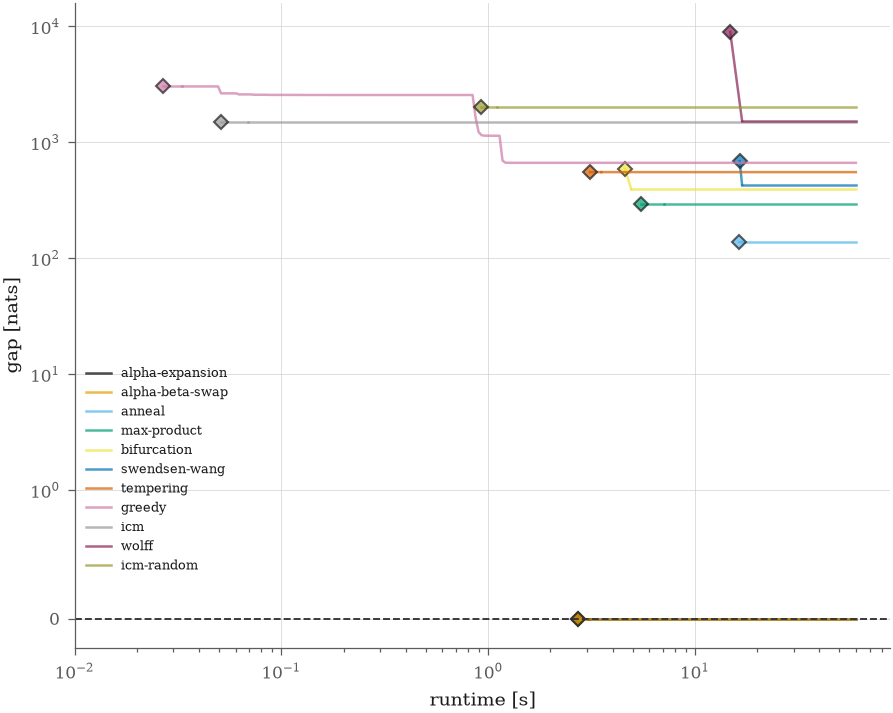

In [8]:
#: The log-spaced grid of seconds every seed is read on.
GRID = np.geomspace(1e-4, 60.0, 400)

#: Draw each solver's ±1 standard-deviation band; off by default, since with
#: every solver on the axes the bands hide the curves.
SHOW_BANDS = False

# Each solver's seeds as curves, its band on the grid, and its mean final gap:
# the legend's order, lowest first, which is also the order colours are dealt.
curves = result.curves()
final = {n: float(np.mean([c.gaps[-1] for c in cs])) for n, cs in curves.items()}
ranked = sorted(ORDER, key=final.__getitem__)
with notebook_style():
    figure = gap_panels(
        {rung.name: {n: curve_band(curves[n], GRID) for n in ranked}},
        {rung.name: final},
        start_styles(ranked),
        ylabel="gap [nats]",
        show_bands=SHOW_BANDS,
        titled=False,
        legend_above=0.1,
    )
    plt.show()

## Read

**The graph cuts reach the exact two-state ground state, and nothing reaches
below it.** Alpha-expansion and alpha-beta swap hand over -10,454.16 on every
seed. That is the graph-cut ground state of the same fixture at `q = 2`
(`RELEASE_Q2_ENERGY`, -10,454.156 in `test_ground_state.py`). Their labelling
uses only the ladder's two ends, 3,286 and 1,755 sites, with a tilt of 0.215
against that ground state's 0.2151. The ten-state optimum is at most this
energy and at least the bracket's -11,521.58. So no solver here has shown the
eight inner classes lower the energy; that is a finding about the instance, as
it was at `q = 3` (issue #906).

**Nothing else reaches it, before or after the polish.** Annealing ends
138.0 ± 32.8 above it and max-product 293.7. Bifurcation and Swendsen-Wang end
393.7 and 430.1, tempering 553.6, and greedy 666.1 after ICM takes it down from
3,036.1. Wolff, ICM and ICM in a random order end 1,510 to 2,000 above.

**Wolff underspends its budget, and this is where it shows.** Its annealed
run takes one cluster per step, for as many steps as a heat-bath sweep budget
buys (`search.ground_state`). It hands over 8,977.2 above the expansion, the
worst of any solver, and ICM brings it to 1,532.6.

**The budget is 1,000 sweeps, and every solver fits it.** Swendsen-Wang on its
compiled pass and ICM in a random order on the compiled sweep (issue #923) took
the longest cell from 100 s to 16.7 s of the 120 s ceiling. At the 300 sweeps
#927 had cut to, annealing ended 295.3 ± 71.1 above: the ranking below the
graph cuts is a statement at the budget. Where each solver first fails as the
budget shrinks is #596's question.

## Further work

- Whether the ten-state optimum lies below the expansion needs a bound tighter
  than the factor-2 bracket, the plaquette dual of `search.tightening`: issue
  #920.
- The learned policy of `learn.potts` is not among the solvers; it has not been
  run at 5,041 sites: issue #920.
- The cluster moves' exactness in a per-site field is asserted by construction
  and not yet against enumeration, and Wolff's per-step adjacency copy is the
  cost at small clusters: issue #919.
- The solvers run at one budget in site visits; a sweep over the budget, where
  each first fails, is issue #596's.